<a href="https://colab.research.google.com/github/pravi-x/gif_invitation_creator/blob/main/gif_invitation_creator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎉 GIF Invitation Creator
Upload **Image 1** (hero/background) and **Image 2** (event details). Choose a transition. Export animated GIF.

---

In [1]:
# Install deps
!pip install pillow imageio -q

In [2]:
import os
from PIL import Image, ImageDraw, ImageFilter, ImageEnhance
import imageio
import numpy as np
from google.colab import files
from IPython.display import display, Image as IPImage

print('Libraries loaded ✓')

Libraries loaded ✓


## Step 1 — Upload your images

In [4]:
print('Upload Image 1 (hero / background):')
up1 = files.upload()
img1_path = list(up1.keys())[0]

print('\nUpload Image 2 (event details):')
up2 = files.upload()
img2_path = list(up2.keys())[0]

print(f'\n✓ Got: {img1_path}  +  {img2_path}')

Upload Image 1 (hero / background):


Saving Διαφάνεια1.JPG to Διαφάνεια1 (1).JPG

Upload Image 2 (event details):


Saving Διαφάνεια2.JPG to Διαφάνεια2.JPG

✓ Got: Διαφάνεια1 (1).JPG  +  Διαφάνεια2.JPG


## Step 2 — Config

In [24]:
# ── USER CONFIG ──────────────────────────────────────────────────────────────

OUTPUT_SIZE   = (800, 600)   # (width, height) px — both images resized to this
HOLD_FRAMES_1 = 25           # frames Image 1 stays on screen
HOLD_FRAMES_2 = 100          # frames Image 2 stays on screen (longer = more reading time)
FRAME_DELAY   = 60           # ms per frame in final GIF
LOOP_COUNT    = 0            # 0 = loop forever
OUTPUT_FILE   = 'invitation.gif'

# Pick ONE transition (comment out the others):
TRANSITION    = 'glitter_wipe'   # options below ↓
# TRANSITION  = 'crossfade'
# TRANSITION  = 'slide_left'
# TRANSITION  = 'zoom_blur'
# TRANSITION  = 'sparkle_fade'
# TRANSITION  = 'shatter'

TRANS_FRAMES  = 30           # frames used for transition animation

# ─────────────────────────────────────────────────────────────────────────────
print(f'Config ready. Transition: {TRANSITION}')

Config ready. Transition: glitter_wipe


## Step 3 — Transition engine

In [20]:
def load_and_resize(path, size):
    img = Image.open(path).convert('RGBA')
    img = img.resize(size, Image.LANCZOS)
    return img


def ease_in_out(t):
    """Smooth cubic ease."""
    return t * t * (3 - 2 * t)


# ── TRANSITIONS ──────────────────────────────────────────────────────────────

def crossfade(img1, img2, n):
    frames = []
    for i in range(n):
        alpha = ease_in_out(i / (n - 1))
        frame = Image.blend(img1, img2, alpha)
        frames.append(frame)
    return frames


def slide_left(img1, img2, n):
    w, h = img1.size
    frames = []
    for i in range(n):
        t = ease_in_out(i / (n - 1))
        offset = int(t * w)
        canvas = Image.new('RGBA', (w, h))
        canvas.paste(img1.crop((offset, 0, w, h)), (0, 0))
        canvas.paste(img2.crop((0, 0, offset, h)), (w - offset, 0))
        frames.append(canvas)
    return frames


def zoom_blur(img1, img2, n):
    frames = []
    for i in range(n):
        t = i / (n - 1)
        if t < 0.5:
            # Zoom + blur out img1
            scale = 1 + t * 0.4
            blur_r = t * 12
            src = img1
            alpha_blend = 1 - t * 2
        else:
            # Zoom in img2 from blurred
            scale = 1.2 - (t - 0.5) * 0.4
            blur_r = (1 - t) * 12
            src = img2
            alpha_blend = (t - 0.5) * 2

        w, h = src.size
        nw, nh = int(w * scale), int(h * scale)
        zoomed = src.resize((nw, nh), Image.LANCZOS)
        left = (nw - w) // 2
        top  = (nh - h) // 2
        cropped = zoomed.crop((left, top, left + w, top + h))
        if blur_r > 0:
            cropped = cropped.filter(ImageFilter.GaussianBlur(radius=blur_r))

        if t < 0.5:
            frame = Image.blend(cropped, Image.new('RGBA', (w, h), (0, 0, 0, 255)), 1 - alpha_blend)
        else:
            frame = Image.blend(Image.new('RGBA', (w, h), (0, 0, 0, 255)), cropped, alpha_blend)
        frames.append(frame)
    return frames


def glitter_wipe(img1, img2, n):
    """Diagonal wipe with shimmering glitter sparkles."""
    w, h = img1.size
    arr1 = np.array(img1, dtype=np.float32)
    arr2 = np.array(img2, dtype=np.float32)
    frames = []
    rng = np.random.default_rng(42)

    # Precompute diagonal distance map (0→1 top-left to bottom-right)
    xs = np.linspace(0, 1, w)
    ys = np.linspace(0, 1, h)
    XX, YY = np.meshgrid(xs, ys)
    diag = (XX + YY) / 2  # 0..1

    for i in range(n):
        t = ease_in_out(i / (n - 1))
        # Wipe mask: pixels where diag < t show img2
        edge_w = 0.08  # soft edge width
        blend = np.clip((t - diag) / edge_w + 0.5, 0, 1)[..., None]  # (H,W,1)

        composed = arr1 * (1 - blend) + arr2 * blend

        # Glitter: random bright pixels near wipe edge
        edge_mask = (np.abs(diag - t) < edge_w).astype(np.float32)
        sparks = rng.random((h, w)) < (edge_mask * 0.18)
        composed[sparks] = [255, 220, 80, 255]   # gold sparkle

        # Extra white flash sparks
        sparks2 = rng.random((h, w)) < (edge_mask * 0.07)
        composed[sparks2] = [255, 255, 255, 255]

        frames.append(Image.fromarray(np.clip(composed, 0, 255).astype(np.uint8), 'RGBA'))
    return frames


def sparkle_fade(img1, img2, n):
    """Random pixel dissolution + sparkle overlay."""
    w, h = img1.size
    arr1 = np.array(img1)
    arr2 = np.array(img2)
    frames = []
    rng = np.random.default_rng(7)
    order = rng.permutation(w * h)  # fixed random pixel reveal order

    for i in range(n):
        t = ease_in_out(i / (n - 1))
        cutoff = int(t * w * h)
        mask_flat = np.zeros(w * h, dtype=bool)
        mask_flat[order[:cutoff]] = True
        mask = mask_flat.reshape(h, w, 1)

        composed = np.where(mask, arr2, arr1).astype(np.float32)

        # Sparkle at boundary
        boundary = rng.random((h, w)) < 0.005
        edge_pixels = boundary & mask_flat.reshape(h, w)
        composed[edge_pixels] = [255, 240, 100, 255]

        frames.append(Image.fromarray(np.clip(composed, 0, 255).astype(np.uint8), 'RGBA'))
    return frames


def shatter(img1, img2, n):
    """Image 1 breaks into tiles that fly away revealing img2."""
    w, h = img1.size
    COLS, ROWS = 8, 6
    tw, th = w // COLS, h // ROWS
    rng = np.random.default_rng(13)

    # Each tile gets a random trajectory
    tile_vx = (rng.random((ROWS, COLS)) - 0.5) * 2   # -1..1
    tile_vy = rng.random((ROWS, COLS)) * 1.5 + 0.5    # downward
    tile_delay = rng.random((ROWS, COLS)) * 0.4        # stagger

    frames = []
    for i in range(n):
        t = i / (n - 1)
        canvas = img2.copy()
        overlay = Image.new('RGBA', (w, h), (0, 0, 0, 0))

        for r in range(ROWS):
            for c in range(COLS):
                d = tile_delay[r, c]
                local_t = max(0, (t - d) / (1 - d)) if d < 1 else 0
                local_t = ease_in_out(min(local_t, 1))

                tx = int(c * tw + tile_vx[r, c] * local_t * w * 0.6)
                ty = int(r * th + tile_vy[r, c] * local_t * h * 0.8)
                alpha = int((1 - local_t) * 255)

                tile = img1.crop((c * tw, r * th, (c+1)*tw, (r+1)*th)).copy()
                tile.putalpha(alpha)

                if 0 <= tx < w and 0 <= ty < h:
                    overlay.paste(tile, (tx, ty), tile)

        canvas = Image.alpha_composite(canvas, overlay)
        frames.append(canvas)
    return frames


TRANSITIONS = {
    'crossfade':    crossfade,
    'slide_left':   slide_left,
    'zoom_blur':    zoom_blur,
    'glitter_wipe': glitter_wipe,
    'sparkle_fade': sparkle_fade,
    'shatter':      shatter,
}

print('Transition functions loaded ✓')
print('Available:', list(TRANSITIONS.keys()))

Transition functions loaded ✓
Available: ['crossfade', 'slide_left', 'zoom_blur', 'glitter_wipe', 'sparkle_fade', 'shatter']


## Step 4 — Build & export GIF

Loading images...
Running transition: glitter_wipe...


/tmp/ipykernel_2576/2109495772.py:101: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  frames.append(Image.fromarray(np.clip(composed, 0, 255).astype(np.uint8), 'RGBA'))


Img2 will show for 15s (150 frames x 100ms)
Saving 205 frames to invitation.gif...

✓ Done! invitation.gif  (5274 KB, 205 frames)


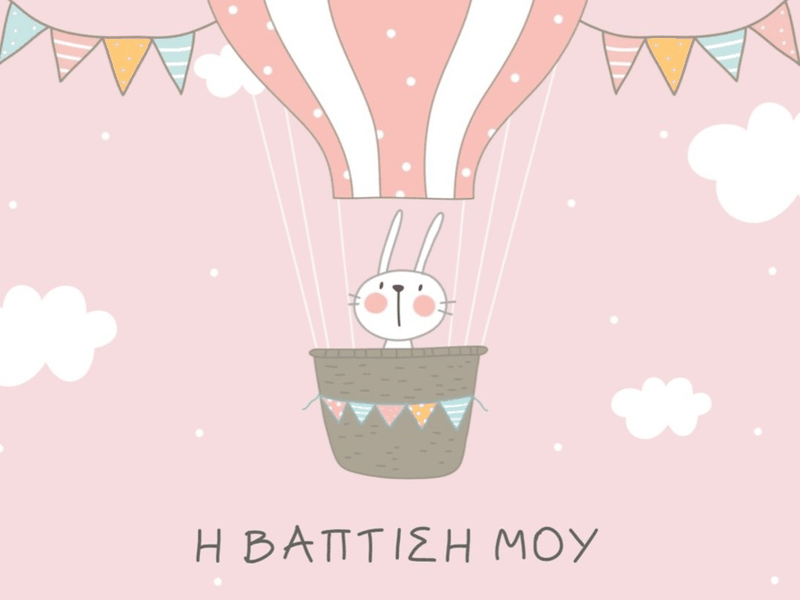

In [25]:
print('Loading images...')
img1 = load_and_resize(img1_path, OUTPUT_SIZE)
img2 = load_and_resize(img2_path, OUTPUT_SIZE)

print(f'Running transition: {TRANSITION}...')
trans_fn = TRANSITIONS[TRANSITION]
trans_frames = trans_fn(img1, img2, TRANS_FRAMES)

# Assemble full sequence with per-frame timing
IMG2_SECONDS = 15        # seconds img2 stays visible — change this
HOLD_DELAY   = 0.1       # 100ms per hold frame (browser-safe minimum)
TRANS_DELAY  = FRAME_DELAY / 1000
hold2_frames = max(1, int(IMG2_SECONDS / HOLD_DELAY))

all_frames = []
all_durations = []
all_frames += [img1] * HOLD_FRAMES_1
all_durations += [HOLD_DELAY] * HOLD_FRAMES_1
all_frames += trans_frames
all_durations += [TRANS_DELAY] * len(trans_frames)
all_frames += [img2] * hold2_frames
all_durations += [HOLD_DELAY] * hold2_frames
print(f'Img2 will show for {IMG2_SECONDS}s ({hold2_frames} frames x {HOLD_DELAY*1000:.0f}ms)')

# Convert to RGB (GIF doesn't do alpha well)
rgb_frames = []
bg = Image.new('RGB', OUTPUT_SIZE, (255, 255, 255))
for f in all_frames:
    flat = bg.copy()
    flat.paste(f, mask=f.split()[3] if f.mode == 'RGBA' else None)
    rgb_frames.append(flat)

print(f'Saving {len(rgb_frames)} frames to {OUTPUT_FILE}...')
# Use Pillow directly — correctly writes per-frame delays
# duration in Pillow is milliseconds per frame
pil_durations = [int(d * 1000) for d in all_durations]
rgb_frames[0].save(
    OUTPUT_FILE,
    format='GIF',
    save_all=True,
    append_images=rgb_frames[1:],
    duration=pil_durations,
    loop=LOOP_COUNT,
    optimize=False
)

size_kb = os.path.getsize(OUTPUT_FILE) / 1024
print(f'\n✓ Done! {OUTPUT_FILE}  ({size_kb:.0f} KB, {len(rgb_frames)} frames)')

# Preview
display(IPImage(filename=OUTPUT_FILE, width=500))

## Step 5 — Download

In [26]:
files.download(OUTPUT_FILE)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>